In [1]:
#| output: false
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from src.io import generic_preproc, get_targets
from omegaconf import DictConfig
from scipy.io import loadmat
from src.ofc_model import CSTProblem
from ioc.methods.solvers import TodorovSOC

%matplotlib inline

/opt/homebrew/Caskroom/mambaforge/base/envs/feedback-machinery/lib/python3.10/site-packages/torchmetrics/utilities/imports.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [28]:
problem = CSTProblem(
    lam=5,
    signal_dependent_noise_const=0,
    motor_noise_const=0.4,
    hand_obs_noise=1e-3,
    T=800,
    dt=0.004,
    delay=0.06,
    control_cost_exp=2,
    pos_cost_exp=-10,
    vel_cost_exp=2,
)

# initialize Todorov solver and run
soc = TodorovSOC(problem)
max_iter = 50
eps = 1e-14
costs = soc.run(max_iter=max_iter, eps=eps)

num_simulations = 20
Xa = soc.avg_trajectory()
XObs, cost_sim, XSim, Xhat, Us = soc.simulate_trajectories(num_simulations,return_x_sim=True)

<Axes: >

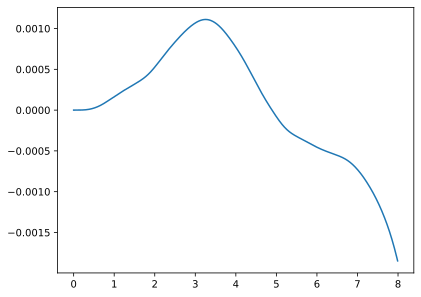

In [31]:
sns.lineplot(x=np.arange(0,8,0.01),y=XSim[0,1,:])

In [4]:
XSim.shape

(80, 20, 800)

In [5]:
ll = lambda p,v: ApproximateInferenceFactory.create(CSTProblem(
    T=800,
    control_cost_exp=2,
    pos_cost_exp=p,
    vel_cost_exp=v,
)).log_likelihood(XSim[:,11,:][:,None,:])

ll(12,1.5)

NameError: name 'ApproximateInferenceFactory' is not defined

In [22]:
inf = ApproximateInferenceFactory.create(problem,soc)
inf.log_likelihood(XSim[:,11,:][:,None,:])

Array(195968.71669449, dtype=float64)

In [27]:
mu, Sigma = inf.conditional_moments(XSim)
mu.shape, Sigma.shape

((799, 20, 70), (799, 20, 70, 70))

In [117]:
from ioc.methods.infer import ApproximateInferenceFactory
from src.ofc_model import get_cst_pos_control, get_cst_vel_control
pos_model = get_cst_pos_control(lam=4)
vel_model = get_cst_vel_control(lam=4)
pos_inf = ApproximateInferenceFactory.create(pos_model)
vel_inf = ApproximateInferenceFactory.create(vel_model)
pos_ll = pos_inf.log_likelihood(XObs[:,11,:][:,None,:])
vel_ll = vel_inf.log_likelihood(XObs[:,11,:][:,None,:])
pos_ll, vel_ll

(Array(9599.55324967, dtype=float64), Array(9597.65166771, dtype=float64))

In [118]:
pos_mu, pos_Sigma = pos_inf.conditional_moments(XObs)
vel_mu, vel_Sigma = vel_inf.conditional_moments(XObs)

In [9]:
pos_mu.shape, vel_mu.shape

((799, 20, 72), (799, 20, 72))

NameError: name 'pos_mu' is not defined

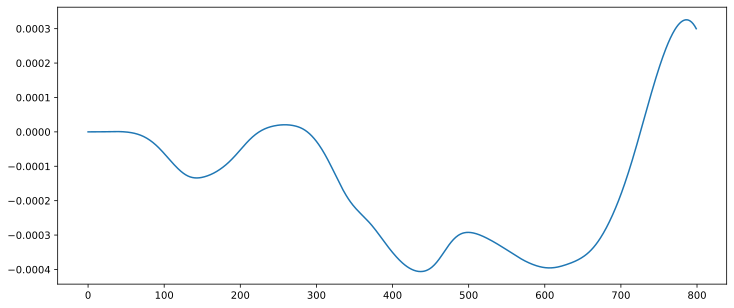

In [6]:
from matplotlib import pyplot as plt
trial = 15
comp = 0
num_states = XSim.shape[0]
fig,ax = plt.subplots(1,1,figsize=(12,5))
ax.plot(XSim[comp,trial,:], label='sim x')
ax.plot(pos_mu[:,trial,num_states+comp], label='pos mu x')
ax.plot(vel_mu[:,trial,num_states+comp], label='vel mu x')

In [10]:
from ioc.methods.mle import max_likelihood

x0 = dict(
    pos_cost_exp= 0,
    vel_cost_exp=0,
)
res = max_likelihood(
    CSTProblem,
    XObs[:,11,:][:,None,:],
    x0=None,
    method='L-BFGS-B',
    bounds={'pos_cost_exp': (-15,15), 'vel_cost_exp': (-15,15)},
    ntimes=5,
)
res.x

2026-01-27 00:20:48.623218: E external/xla/xla/service/slow_operation_alarm.cc:73] 
********************************
[Compiling module jit_nll] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
2026-01-27 00:20:52.718766: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 2m4.096217s

********************************
[Compiling module jit_nll] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


{'pos_cost_exp': Array(-15., dtype=float64),
 'vel_cost_exp': Array(-15., dtype=float64)}

In [11]:
res.success

True

In [ ]:
mat_data = loadmat('/Users/raeed/codebase/0-projects/cst-rtt/eLife_code_and_data/data/temp_data.mat', simplify_cells=True,variable_names=['data'])
renamer = {
    'subjectID': 'subject',
    'trialType': 'task',
    'trialNumber': 'trial_id',
    'sessionNumber': 'session',
    'instruction_type': 'control instruction',
    'lambdaUpdateMode': 'lambda update mode',
    't': 'time',
    'x': 'cursor position',
    'u': 'hand position',
}

def condition_trial(trial):
    t = trial['time']
    x = trial['cursor position']
    u = trial['hand position']

    last_pretrial_idx = np.argmin(np.diff(t))
    trial_slice = slice(last_pretrial_idx,None,None)

    new_t = pd.timedelta_range(start=0, periods=len(t[trial_slice]), freq='4ms')

    new_trial = pd.Series(
        {
            'time': new_t,
            'cursor position': x[trial_slice],
            'hand position': u[trial_slice,0]
        },
        name = trial.name,
    )
    
    return new_trial

human_data = (
    pd.DataFrame(mat_data['data'])
    .rename(columns=renamer)
    [['subject','session','task','lambda update mode','trial_id','lambda','success','control instruction','time','cursor position','hand position']]
    .assign(**{
        'lambda update mode': lambda df: df['lambda update mode'].map(lambda x: x if type(x) is str else '')
    })
    .astype({
        'subject': 'category',
        'session': int,
        'task': 'category',
        'lambda update mode': 'category',
        'trial_id': int,
        'lambda': float,
        'success': bool,
        'control instruction': 'category',
    })
    .set_index(['subject','session','task','lambda update mode','trial_id','control instruction','lambda','success'])
    .xs(level='task',key='CST')
    .apply(condition_trial, axis=1)
    .explode(['time','cursor position','hand position'])
    .set_index('time', append=True)
    .astype({
        'cursor position': float,
        'hand position': float,
    })
    .rename_axis('signal', axis=1)
)

human_data

signal                                                                                                 cursor position  \
subject session lambda update mode trial_id control instruction lambda success time                                      
AB      0       dynamic            1        position            2.000  False   0 days 00:00:00                0.000000   
                                                                               0 days 00:00:00.004000        -0.002209   
                                                                               0 days 00:00:00.008000        -0.005352   
                                                                               0 days 00:00:00.012000        -0.008416   
                                                                               0 days 00:00:00.016000        -0.011664   
...                                                                                                                ...   
WP      3       rand               20       position            4.402  False   0 days 00:00:02.664000       -97.155760   
                                                                               0 days 00:00:02.668000       -97.859301   
                                                                               0 days 00:00:02.672000       -98.732848   
                                                                               0 days 00:00:02.676000       -99.546797   
                                                                               0 days 00:00:02.680000      -100.298215   

signal                                                                                                 hand position  
subject session lambda update mode trial_id control instruction lambda success time                                   
AB      0       dynamic            1        position            2.000  False   0 days 00:00:00             -0.369904  
                                                                               0 days 00:00:00.004000      -0.367126  
                                                                               0 days 00:00:00.008000      -0.389038  
                                                                               0 days 00:00:00.012000      -0.376221  
                                                                               0 days 00:00:00.016000      -0.395844  
...                                                                                                              ...  
WP      3       rand               20       position            4.402  False   0 days 00:00:02.664000      39.915649  
                                                                               0 days 00:00:02.668000      44.231506  
                                                                               0 days 00:00:02.672000      48.685181  
                                                                               0 days 00:00:02.676000      52.910828  
                                                                               0 days 00:00:02.680000      57.244995  

[15062466 rows x 2 columns]

/var/folders/wf/m89rq9p97kq6fdqj23hkrm_h0000gn/T/ipykernel_59084/2569574473.py:3: PerformanceWarning: indexing past lexsort depth may impact performance.
  human_data


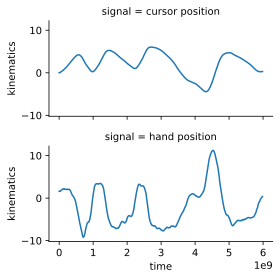

In [ ]:
# example real trial
trial = (
    human_data
    .loc[('AB',1,'ramp',2)]
)
sns.relplot(
    data=(
        trial
        .stack()
        .to_frame(name='kinematics')
    ),
    row='signal',
    x='time',
    y='kinematics',
    kind='line',
    aspect=2,
    height=2,
)

In [ ]:
from trialframe import get_index_level
import jax.numpy as jnp
trial_lambda = get_index_level(trial, 'lambda').iloc[0]
cst_observation = jnp.array(
    trial
    [['cursor position','hand position']]
    .to_numpy()
    .T
    [:,None,:]
)

model_kwargs = dict(
    T=cst_observation.shape[2],
    lam=trial_lambda,
    dt=0.004,
    hand_obs_noise=0,
)

pos_model = get_cst_pos_control(**model_kwargs)
vel_model = get_cst_vel_control(**model_kwargs)
pos_inf = ApproximateInferenceFactory.create(pos_model)
vel_inf = ApproximateInferenceFactory.create(vel_model)
pos_ll = pos_inf.log_likelihood(cst_observation)
vel_ll = vel_inf.log_likelihood(cst_observation)
pos_ll, vel_ll

(Array(-1828745.97143733, dtype=float64),
 Array(-462496.72931243, dtype=float64))

In [ ]:
pos_mu, pos_Sigma = pos_inf.conditional_moments(cst_observation)
vel_mu, vel_Sigma = vel_inf.conditional_moments(cst_observation)

In [ ]:
pos_Sigma.shape

(1496, 1, 162, 162)

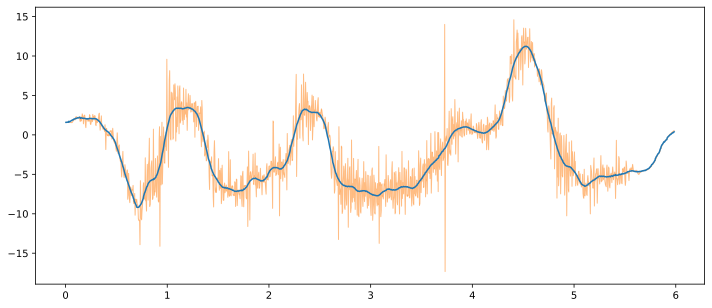

In [ ]:
num_states = pos_model.xdim
trialnum = 0
comp = 2
t = get_index_level(trial, 'time').dt.total_seconds()[1:]
fig,ax = plt.subplots(1,1,figsize=(12,5))
ax.plot(t,cst_observation[comp,trialnum,1:], label='obs x')
# ax.plot(t,pos_mu[:,trialnum,num_states+comp], label='pos mu x')
# ax.plot(t,vel_mu[:,trialnum,num_states+comp], label='vel mu x')

# pos_std = jnp.sqrt(pos_Sigma[:,trialnum,num_states+comp,num_states+comp])
ax.fill_between(t, pos_mu[:,trialnum,num_states+comp] - pos_std * 2, pos_mu[:,trialnum,num_states+comp] + pos_std * 2, alpha=0.5, color="C1", label="experimenter's uncertainty")

In [ ]:
cst_observation[1,0,:]

Array([1.5920105 , 1.58416748, 1.58026123, ..., 0.30947876, 0.32949829,
       0.38619995], dtype=float64)

In [ ]:
from ioc.methods.mle import max_likelihood

x0 = dict(
    pos_cost_exp= 0,
    vel_cost_exp=0,
)
res = max_likelihood(CSTProblem, cst_observation, x0=x0, method="bobyqa")
res.x

{'pos_cost_exp': Array(-2.7974745, dtype=float64),
 'vel_cost_exp': Array(7.12511033, dtype=float64)}

In [ ]:
res.x

{'pos_cost_exp': Array(-2.7974745, dtype=float64),
 'vel_cost_exp': Array(7.12511033, dtype=float64)}

In [ ]:
mle_model = CSTProblem(**res.x)
mle_inf = ApproximateInferenceFactory.create(mle_model)
mle_ll = mle_inf.log_likelihood(cst_observation)
mle_ll

Array(-2.14634036e+08, dtype=float64)

In [ ]:
cst_observation.shape

(2, 1, 1497)

In [ ]:
mle_mu, mle_Sigma = mle_inf.conditional_moments(cst_observation)
mle_mu.shape

(1496, 1, 72)

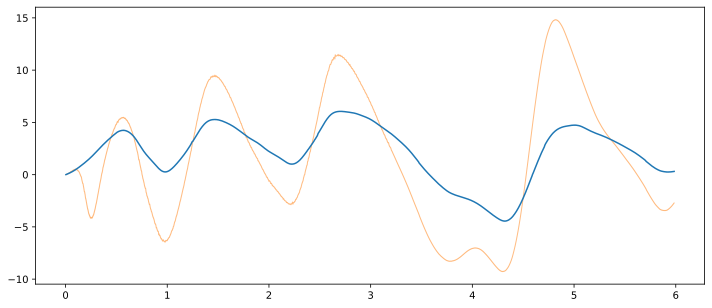

In [ ]:
num_states = mle_model.xdim
trialnum = 0
obs_comp = 0
# model_comp = num_states + obs_comp
model_comp = 35
t = get_index_level(trial, 'time').dt.total_seconds()[1:]
fig,ax = plt.subplots(1,1,figsize=(12,5))
ax.plot(t,cst_observation[obs_comp,trialnum,1:], label='obs x')
# ax.plot(t,mle_mu[:,trialnum,num_states+comp], label='pos mu x')

mle_std = jnp.sqrt(mle_Sigma[:,trialnum,model_comp,model_comp])
ax.fill_between(t, mle_mu[:,trialnum,model_comp] - mle_std * 2, mle_mu[:,trialnum,model_comp] + mle_std * 2, alpha=0.5, color="C1", label="experimenter's uncertainty")